---
title: "Dataset Characterization Notebook 1"
date: 2026-04-19
author: Andrei Akopian
---

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split

In [4]:
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

In [2]:
DIAGNOSIS_RECORDS_TRAIN = "../data/diagnosis_records_train.csv"
PARTICIPANT_DATA_TRAIN = "../data/participant_data_train.csv"
PARTICIPANT_DATA_TEST = "../data/participant_data_test.csv"
WEARABLE_DATA_TRAIN = "../data/wearable_data_train.csv" 

In [5]:
diagnosis_records_train = pd.read_csv(DIAGNOSIS_RECORDS_TRAIN)
participant_data_train = pd.read_csv(PARTICIPANT_DATA_TRAIN)
participant_data_test = pd.read_csv(PARTICIPANT_DATA_TEST)
wearable_data_train = pd.read_csv(WEARABLE_DATA_TRAIN)

# Simple baseline based on mortality risk etc.

In [35]:
def generate_actuarial_baseline(df):
    def get_who_rate(age):
        if age < 25: return 0.00467
        if age < 30: return 0.00593
        if age < 35: return 0.00705
        if age < 40: return 0.00850
        if age < 45: return 0.01054
        if age < 50: return 0.01504
        if age < 55: return 0.02322
        if age < 60: return 0.03548
        if age < 65: return 0.05047
        return 0.07226 # Covers 65+

    # 2. Apply lookup to raw age column
    df['annual_qx'] = df['age'].apply(get_who_rate)

    # 3. Calculate 10-Year Survival Probability (10px)
    # formula: px ^ 10
    df['surv_10yr'] = (1 - df['annual_qx']) ** 10

    # 4. Apply Survival Reductions for Clinical Indicators
    # Instead of increasing death prob by 1.2, we decrease survival prob.
    # A 0.95 or 0.90 multiplier is common for significant comorbidities 
    # to avoid pushing death probabilities over 1.0 unnaturally.
    survival_reduction_factor = 0.90 
    
    # condition_cols = [
    #     'diagnosed_diabetes', 'diagnosed_afib', 
    #     'diagnosed_hypertension', 'diagnosed_sleep_apnea',
    #     'smoker'
    # ]
    
    # for col in condition_cols:
    #     # If the condition exists (1), multiply the survival chance by 0.90
    #     df['surv_10yr'] = np.where(df[col] >= 1, df['surv_10yr'] * survival_reduction_factor, df['surv_10yr'])

    # 5. Final Step: Subtract from 1 to get Death Probability (10qx)
    df['predicted_probability'] = 1 - df['surv_10yr']
    
    # Ensure the result is bounded between 0 and 1
    df['predicted_probability'] = df['predicted_probability'].clip(0.0, 1.0)
    
    return df[['ID', 'predicted_probability']]

In [36]:
baseline_results = generate_actuarial_baseline(participant_data_train)

<Axes: xlabel='predicted_probability', ylabel='Count'>

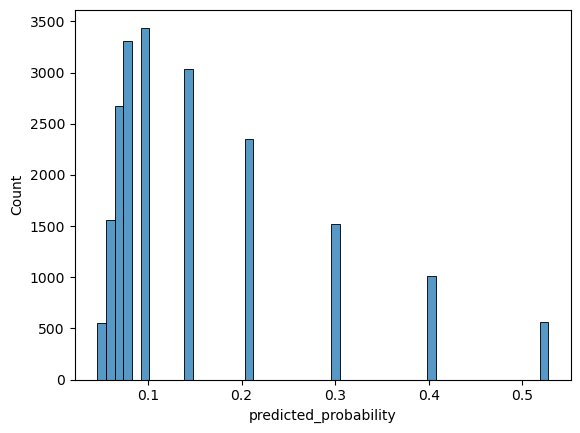

In [40]:
sns.histplot(baseline_results["predicted_probability"])

In [11]:
def evaluate_mortality_model(actual_outcomes, predicted_probs):
    """
    Evaluates predictive performance, calibration, and discrimination.
    """
    # 1. Log-Loss (Competition Primary Metric) [cite: 50, 107]
    ll_score = log_loss(actual_outcomes, predicted_probs)
    
    # 2. Brier Score (Calibration Metric)
    brier_score = brier_score_loss(actual_outcomes, predicted_probs)
    
    # 3. C-index / AUC (Discrimination Metric)
    # Measures the probability that a person who died was assigned 
    # a higher risk than a person who survived.
    c_index = roc_auc_score(actual_outcomes, predicted_probs)
    
    # 4. Actuarial Reasonableness (A/E Ratio) [cite: 89, 90]
    mean_actual = np.mean(actual_outcomes)
    mean_pred = np.mean(predicted_probs)
    ae_ratio = mean_actual / mean_pred if mean_pred != 0 else 0
    
    return {
        "Log-Loss": round(ll_score, 5),
        "Brier Score": round(brier_score, 5),
        "C-index (AUC)": round(c_index, 5),
        "Actual Mortality Rate": round(mean_actual, 5),
        "Predicted Mortality Rate": round(mean_pred, 5),
        "A/E Ratio": round(ae_ratio, 3)
    }

In [12]:
results = evaluate_mortality_model(participant_data_train['outcome'], baseline_results['predicted_probability'])
print(results)

{'Log-Loss': 0.29555, 'Brier Score': 0.07768, 'C-index (AUC)': 0.51279, 'Actual Mortality Rate': np.float64(0.08095), 'Predicted Mortality Rate': np.float64(0.08129), 'A/E Ratio': np.float64(0.996)}


In [23]:
def train_and_predict_baseline(train_df, test_df):
    # 1. Feature Selection & Preprocessing
    features = [
        'age', 'bmi', 'smoker', 'diagnosed_afib', 
        'diagnosed_diabetes', 'diagnosed_hypertension'
    ]
    
    # Ensure sex is encoded if you wish to use it (0=M, 1=F)
    train_df['is_female'] = (train_df['sex'] == 'F').astype(int)
    test_df['is_female'] = (test_df['sex'] == 'F').astype(int)
    features.append('is_female')

    # 2. Train Logistic Regression
    # Logistic regression naturally models probabilities in the (0, 1) range
    X = sm.add_constant(train_df[features])
    y = train_df['outcome']
    
    model = sm.Logit(y, X).fit()
    
    # 3. Predict on Test Set
    X_test = sm.add_constant(test_df[features])
    # model.predict returns the probability of the 'outcome' being 1 (Death)
    test_df['predicted_probability'] = model.predict(X_test)
    
    return test_df[['ID', 'predicted_probability']], model

In [42]:
train_subset, validation_subset = train_test_split(participant_data_train, train_size=0.5)

In [43]:
baseline_results, model = train_and_predict_baseline(train_subset, validation_subset)

Optimization terminated successfully.
         Current function value: 0.261626
         Iterations 7


In [45]:
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Logit
=======================================================================
Model:                Logit              Method:             MLE       
Dependent Variable:   outcome            Pseudo R-squared:   0.061     
Date:                 2026-04-19 15:03   AIC:                5248.5188 
No. Observations:     10000              BIC:                5306.2016 
Df Model:             7                  Log-Likelihood:     -2616.3   
Df Residuals:         9992               LL-Null:            -2787.7   
Converged:            1.0000             LLR p-value:        4.1404e-70
No. Iterations:       7.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                  -5.2900   0.2609 -20.2746 0.0000 -5.8014 -4.7786
age                     0.0530   0.0036  14.8071 0.0000  0.0460  0.0600
bmi                     0.0126   0.0067   1.8817 0.0599 -0.0005  0.0257
smoker                  0.6208   0.0948   6.5485 0.0000  0.4350  0.8066
diagnosed_afib          1.8253   0.2615   6.9811 0.0000  1.3128  2.3378
diagnosed_diabetes      0.1113   0.1498   0.7431 0.4574 -0.1823  0.4050
diagnosed_hypertension -0.1075   0.1144  -0.9395 0.3475 -0.3316  0.1167
is_female              -0.0777   0.0758  -1.0255 0.3051 -0.2263  0.0708
=======================================================================

"""

In [44]:
evaluate_mortality_model(validation_subset['outcome'], baseline_results["predicted_probability"])

{'Log-Loss': 0.26705,
 'Brier Score': 0.07234,
 'C-index (AUC)': 0.68041,
 'Actual Mortality Rate': np.float64(0.0819),
 'Predicted Mortality Rate': np.float64(0.08047),
 'A/E Ratio': np.float64(1.018)}

# Pickle testing

In [46]:
import pickle

In [47]:
def foo(a):
    return a + 10

In [52]:
with open("foo.pkl", "wb") as f:
    pickle.dump(foo, f)

In [53]:
with open("foo.pkl", "rb") as f:
    bar = pickle.load(f)

In [55]:
bar(10)

20